# 0 - Helpers

In [6]:
from notebooks_function import *

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import pypsa
from collections import Counter

def get_cap_all(df_all, carriers, groupby_list):
    cols = {}
    
    # Get list of years from the ind
    all_years = sorted(df_all.index.get_level_values('year').unique())
    
    # Store solar-hsat p_nom_opt from previous years for each scenario
    solar_hsat_history = {}
    solar_hsat_factor = 1.15
    for year, sc in df_all.index:
        n = df_all.loc[(year, sc)]
        # Use tuple (year, scenario) as column key instead of network name
        gens = n.generators[n.generators.carrier.isin(carriers) & (n.generators.build_year == year)]
        if "country" in groupby_list:
            country_map = n.buses[n.buses.index.isin(gens.bus)].country
            gens["country"] = gens.bus.map(country_map)
        grouped = gens.groupby(groupby_list)[["p_nom", "p_nom_opt", "p_nom_max"]].sum()/1e3

        # Add ratio column
        grouped["share over max"] = grouped["p_nom_opt"] / grouped["p_nom_max"]
        
        # Add solar-utility row
        if "solar" in grouped.index and "solar-hsat" in grouped.index:
            # Determine if we need MultiIndex based on groupby_list
            if "country" in groupby_list:
                # MultiIndex case: create with country level
                countries = grouped.index.get_level_values("country").unique()
                solar_utility = pd.DataFrame(
                    index=pd.MultiIndex.from_product([["solar utility"], countries], names=["carrier", "country"]),
                    columns=grouped.columns,
                    dtype=float
                )
                
                # Get data with .values for array operations
                solar_p_nom_opt = grouped.loc["solar", "p_nom_opt"].values
                solar_hsat_p_nom_opt = grouped.loc["solar-hsat", "p_nom_opt"].values
                solar_p_nom_max = grouped.loc["solar", "p_nom_max"].values
                solar_hsat_p_nom = grouped.loc["solar-hsat", "p_nom"].values
                solar_p_nom = grouped.loc["solar", "p_nom"].values
                solar_hsat_p_nom_val = grouped.loc["solar-hsat", "p_nom"].values
                
            else:
                # Single index case
                solar_utility = pd.DataFrame(
                    index=["solar utility"],
                    columns=grouped.columns,
                    dtype=float
                )
                solar_utility.index.name = "carrier"
                
                # Get data as scalars (no .values needed)
                solar_p_nom_opt = grouped.loc["solar", "p_nom_opt"]
                solar_hsat_p_nom_opt = grouped.loc["solar-hsat", "p_nom_opt"]
                solar_p_nom_max = grouped.loc["solar", "p_nom_max"]
                solar_hsat_p_nom = grouped.loc["solar-hsat", "p_nom"]
                solar_p_nom = grouped.loc["solar", "p_nom"]
                solar_hsat_p_nom_val = grouped.loc["solar-hsat", "p_nom"]
            
            # p_nom_opt: sum of solar and solar-hsat
            solar_utility.loc[:, "p_nom_opt"] = (
                solar_p_nom_opt + 
                solar_hsat_p_nom_opt * solar_hsat_factor
            )
            
            # p_nom_max logic
            if year == all_years[0]:  # First year
                # For first year: p_nom_max solar - p_nom solar-hsat
                solar_utility.loc[:, "p_nom_max"] = (
                    solar_p_nom_max - 
                    solar_hsat_p_nom * solar_hsat_factor
                )
            else:
                # For other years: p_nom_max solar (current year) - p_nom_opt solar-hsat (previous year)
                year_idx = all_years.index(year)
                prev_year = all_years[year_idx - 1]
                prev_solar_hsat_opt = solar_hsat_history.get((sc, prev_year), 0)
                
                if "country" in groupby_list:
                    solar_utility.loc[:, "p_nom_max"] = (
                        solar_p_nom_max - 
                        prev_solar_hsat_opt.values * solar_hsat_factor
                    )
                else:
                    solar_utility.loc[:, "p_nom_max"] = (
                        solar_p_nom_max - 
                        prev_solar_hsat_opt * solar_hsat_factor
                    )
            
            # p_nom: sum of solar and solar-hsat
            solar_utility.loc[:, "p_nom"] = (
                solar_p_nom + 
                solar_hsat_p_nom_val
            )
            
            # share over max
            solar_utility.loc[:, "share over max"] = (
                solar_utility["p_nom_opt"] / solar_utility["p_nom_max"]
            ).where(solar_utility["p_nom_max"] > 0, 0)
            
            # Concatenate solar-utility to grouped
            grouped = pd.concat([grouped, solar_utility])
            
            # Store solar-hsat p_nom_opt for next year
            solar_hsat_history[(sc, year)] = grouped.loc["solar-hsat", "p_nom_opt"]
        
        cols[(year, sc)] = round(grouped, 3)

    df = pd.concat(cols, axis=1).fillna(0)
    # Create MultiIndex columns with year and scenario
    df.columns = pd.MultiIndex.from_tuples(df.columns, names=['year', 'scenario', 'capacity'])
    
    # Create carrier-color dictionary
    color_dict = {i: n.carriers.loc["solar" if i == "solar utility" else i, "color"] for i in df.index.get_level_values("carrier").unique()}
    
    return df, color_dict

def plot_bar(df, colors, ylabel=None, title=None, figsize=(12, 6), vert_lines=True):
    # Create figure and axis with adjustable size
    fig, ax = plt.subplots(figsize=figsize)
    
    # Clean 'virtual ' prefix from index names
    df = clean_virtual_names(df.copy())
    
    # Remove column names from MultiIndex if present
    df_plot = df.copy()
    if isinstance(df_plot.columns, pd.MultiIndex):
        df_plot.columns = df_plot.columns.set_names([None, None])

    # Create stacked bar plot on the provided axis
    df_plot.T.plot(kind="bar", stacked=True, legend=True, color=colors, ax=ax)

    # Reverse legend order
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles[::-1], labels[::-1],
              loc='upper left', bbox_to_anchor=(1, 1),
              title='Carrier')

    # Add total values above each bar
    bar_totals = df.T.sum(axis=1)  # totals per bar
    bar_height = df.clip(lower=0).T.sum(axis=1)
    
    for i, total in enumerate(bar_totals):
        ax.text(
            i,                              # x position
            bar_height.iloc[i],             # y position
            "{:.1f}".format(total),         # label
            ha='center', va='bottom',
            fontsize=9
        )

    # Check if we have MultiIndex columns (year, scenario structure)
    if isinstance(df.columns, pd.MultiIndex):
        # Get years and scenarios
        years = df.columns.get_level_values('year').unique()
        scenarios = df.columns.get_level_values('scenario').unique()
        
        # Set x-axis labels to show only scenarios
        ax.set_xticklabels([sc for _, sc in df.columns], rotation=45, ha='right')
        
        # Add year labels as a secondary x-axis
        # Calculate position for each year group
        year_positions = []
        year_labels = []
        for year in years:
            year_cols = [i for i, (y, s) in enumerate(df.columns) if y == year]
            if year_cols:
                year_positions.append(np.mean(year_cols))
                year_labels.append(str(year))
        
        # Add vertical lines between years
        if vert_lines and len(years) > 1:
            for year in years[:-1]:
                year_cols = [i for i, (y, s) in enumerate(df.columns) if y == year]
                if year_cols:
                    ax.axvline(max(year_cols) + 0.5, color='gray', linestyle='--', linewidth=1)
        
        # Add secondary x-axis for years
        ax2 = ax.twiny()
        ax2.set_xlim(ax.get_xlim())
        ax2.set_xticks(year_positions)
        ax2.set_xticklabels(year_labels)
        ax2.tick_params(axis='x', which='both', length=0)  # Hide tick marks
        ax2.spines['top'].set_visible(False)
    else:
        # Fallback for non-MultiIndex columns (old behavior)
        ax.set_xticklabels(df.columns, rotation=45, ha='right')
        
        if vert_lines:
            group_bars = max(Counter([int(c[-4:]) for c in df.columns]).values())
            num_bars = df.T.shape[0]
            for i in range(0, num_bars, group_bars):
                ax.axvline(i - 0.5, color='gray', linestyle='--', linewidth=1)
    
    # Labels
    if ylabel:
        ax.set_ylabel(ylabel)
    if title:
        ax.set_title(title)

    ax.grid(axis='y')

    return ax


# 1 - Retrieve networks

In [8]:
years = [2025, 2030, 2035, 2040]
scenarios = ["baseline",
             "energy-match-50",
             "hourly-match-50-90",
             "hourly-match-50-95",
             "hourly-match-50-98",
             "hourly-match-50-99",
             ]

# Build MultiIndex
index = pd.MultiIndex.from_product(
    [years, scenarios],
    names=["year", "scenario"]
)

# Create empty DataFrame
df_networks = pd.DataFrame(index=index, columns=["network"])

# Fill it
for year, sc in index:
    try:
        n = pypsa.Network(f"../results/{sc}/networks/base_s_39___{year}.nc")
    except:
        print(f"{sc}-{year} not availabe")
        continue
    n = prepare_network(n)
    n.name = f"{sc}-{year}"
    df_networks.loc[(year, sc), "network"] = n

    m = strip_network_GoO(n)
    m.name = "GoO-" + m.name
    df_networks.loc[(year, sc), "GoO"] = m

df_networks = df_networks.dropna()

INFO:pypsa.network.io:New version 1.0.4 available! (Current: 1.0.2)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores, sub_networks
INFO:pypsa.network.io:New version 1.0.4 available! (Current: 1.0.2)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores, sub_networks
INFO:pypsa.network.io:New version 1.0.4 available! (Current: 1.0.2)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores, sub_networks
INFO:pypsa.network.io:New version 1.0.4 available! (Current: 1.0.2)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores, sub_networks
INFO:pypsa.network.io:New version 1.0.4 available! (Current:

# 2 - Capacity mix - System

### Optimal capacity vs Max capacity

year               2025                                                       \
scenario       baseline                           energy-match-50              
capacity      p_nom_opt  p_nom_max share over max       p_nom_opt  p_nom_max   
carrier                                                                        
offwind-ac        7.451    422.687          0.018           7.450    422.687   
offwind-dc        0.001    257.524          0.000          30.724    257.524   
offwind-float     0.001   2231.082          0.000           0.000   2231.082   
onwind           68.573   8632.901          0.008          78.559   8632.901   
solar           123.971  10789.340          0.011         123.970  10789.340   
solar rooftop     7.037   1020.579          0.007           7.053   1020.579   
solar-hsat      146.925   9504.423          0.015         344.706   9504.423   
solar utility   292.935  10789.340          0.027         520.381  10789.340   

year                                                                       \
scenario                     hourly-match-50-90                             
capacity      share over max          p_nom_opt  p_nom_max share over max   
carrier                                                                     
offwind-ac             0.018             31.928    422.687          0.076   
offwind-dc             0.119             59.505    257.524          0.231   
offwind-float          0.000              0.000   2231.082          0.000   
onwind                 0.009             47.505   8632.901          0.006   
solar                  0.011            123.970  10789.340          0.011   
solar rooftop          0.007              7.053   1020.579          0.007   
solar-hsat             0.036            246.305   9504.423          0.026   
solar utility          0.048            407.220  10789.340          0.038   

year                              ...               2040                     \
scenario      hourly-match-50-95  ... hourly-match-50-90 hourly-match-50-95   
capacity               p_nom_opt  ...     share over max          p_nom_opt   
carrier                           ...                                         
offwind-ac                31.797  ...              0.028             21.462   
offwind-dc                45.078  ...              0.120             19.065   
offwind-float              0.000  ...              0.000              0.013   
onwind                    45.996  ...              0.020            187.792   
solar                    123.970  ...              0.000              6.238   
solar rooftop              7.035  ...              0.826            306.466   
solar-hsat               214.540  ...              0.045            385.827   
solar utility            370.691  ...              0.043            449.939   

year                                                                   \
scenario                                hourly-match-50-98              
capacity       p_nom_max share over max          p_nom_opt  p_nom_max   
carrier                                                                 
offwind-ac       329.420          0.065             24.972    322.153   
offwind-dc       140.558          0.136             21.152    135.569   
offwind-float   2231.082          0.000              0.013   2231.082   
onwind          8461.120          0.022            230.838   8474.077   
solar          10665.532          0.001              8.779  10665.532   
solar rooftop    397.584          0.771            341.119    461.791   
solar-hsat      8842.267          0.044            283.624   8937.527   
solar utility  10571.903          0.043            334.947  10554.801   

year                                                                       
scenario                     hourly-match-50-99                            
capacity      share over max          p_nom_opt  p_nom_max share over max  
carrier                                                     

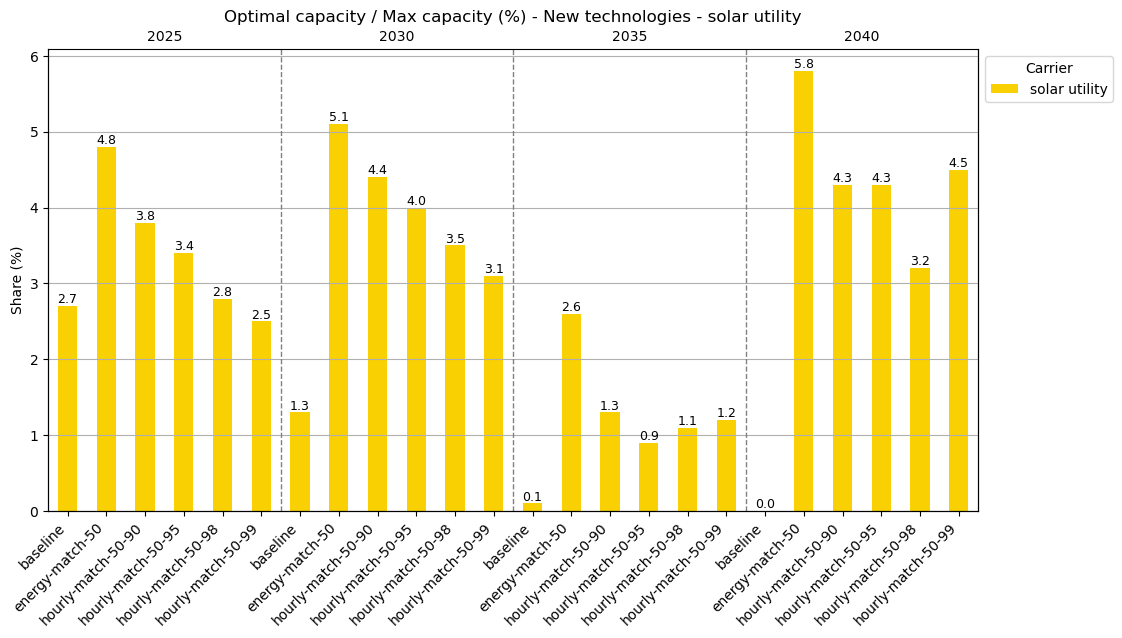

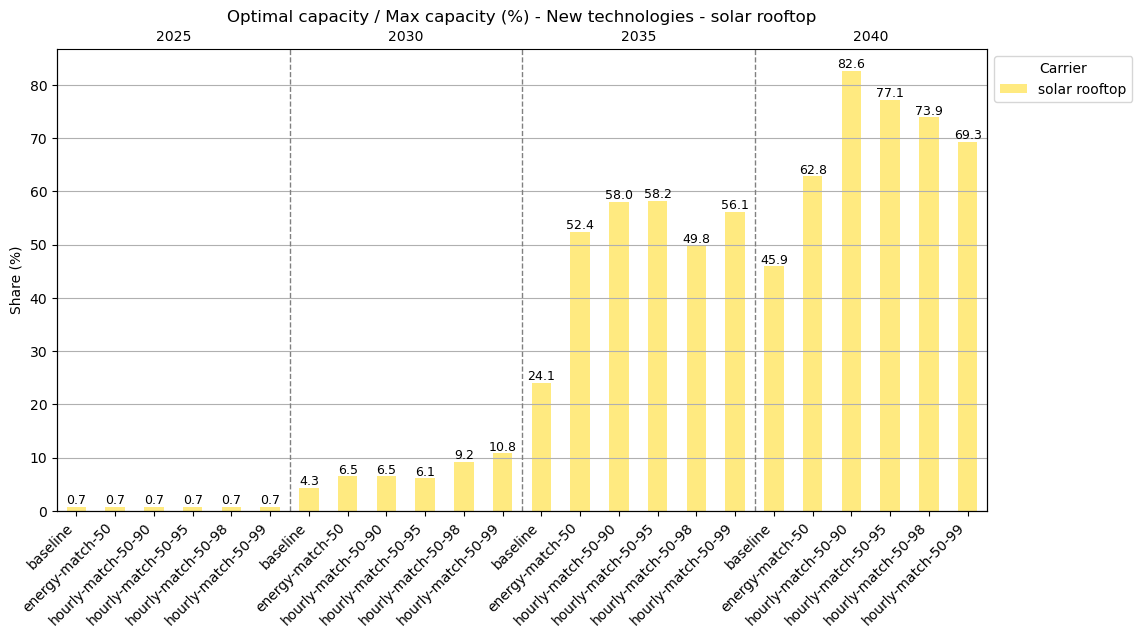

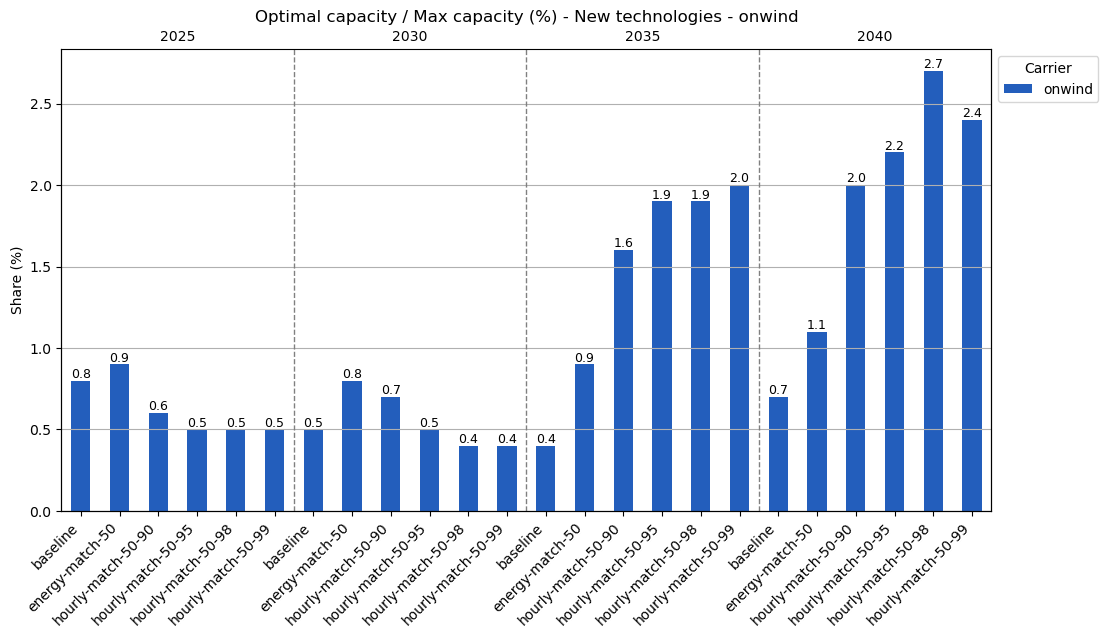

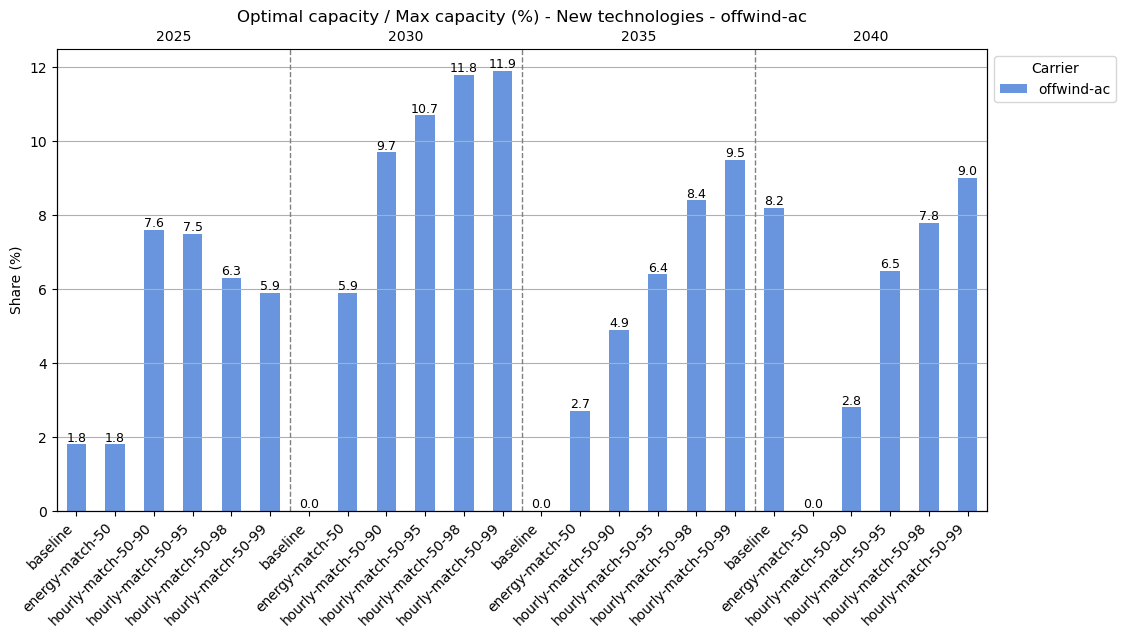

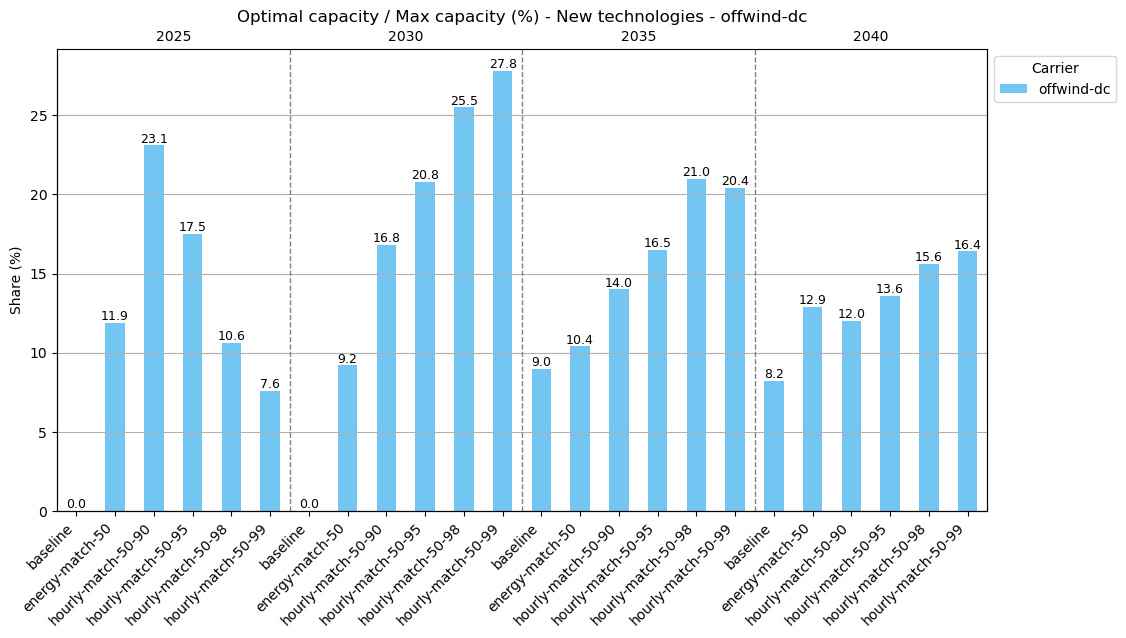

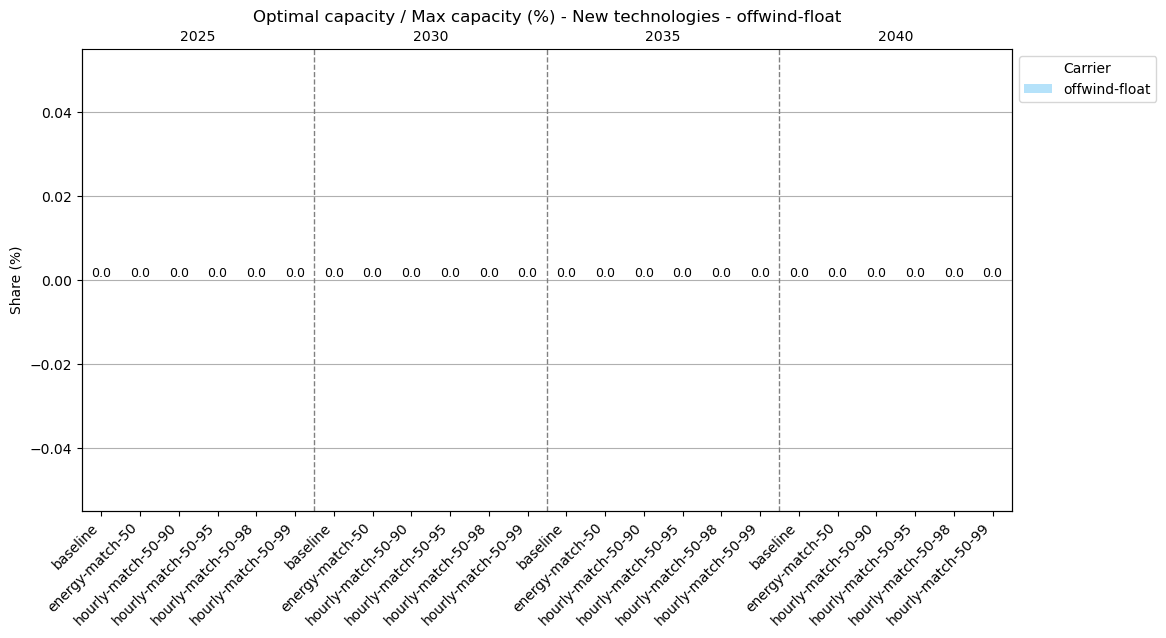

In [9]:
vres_carriers = [
        "solar",
        "solar rooftop",
        "solar-hsat",
        "onwind",
        "offwind-ac",
        "offwind-dc",
        "offwind-float",
    ]
df, colors = get_cap_all(df_networks["network"], carriers=vres_carriers, groupby_list = ["carrier"])
df = df.drop("p_nom", axis=1, level=2)
display(df)
years = df.columns.get_level_values('year').unique()
scenarios = df.columns.get_level_values('scenario').unique()
capacities = df.columns.get_level_values('capacity').unique()

# Use pd.IndexSlice for MultiIndex column selection
idx = pd.IndexSlice
df_plot = df.loc[:, idx[years, scenarios, "share over max"]]
df_plot = df_plot.droplevel('capacity', axis=1)
df_plot = df_plot*100

vres_plot = [
        #"solar",
        "solar utility", # solar + solar-hsat * 1.15 (see add_solar_potential_constraints in solve_network.py)
        "solar rooftop",
        #"solar-hsat",
        "onwind",
        "offwind-ac",
        "offwind-dc",
        "offwind-float",
    ]
for carrier in vres_plot:
    #print("="*40 + f"Analysing {carrier}" + "="*40)
    if carrier not in df_plot.index:
        print(f"Warning: {carrier} not in df_plot index and will be skipped.")
        continue
    ax = plot_bar(df_plot[df_plot.index==carrier], colors[carrier], ylabel="Share (%)", title=f"Optimal capacity / Max capacity (%) - New technologies - {carrier}")

### Access specific years/scenarios/capacities

In [10]:
years = df.columns.get_level_values('year').unique()
scenarios = df.columns.get_level_values('scenario').unique()
capacities = df.columns.get_level_values('capacity').unique()

# Use pd.IndexSlice for MultiIndex column selection
idx = pd.IndexSlice
df.loc[:, idx[years, "hourly-match-50-99", capacities]]

year                        2025                                         2030  \
scenario      hourly-match-50-99                           hourly-match-50-99   
capacity               p_nom_opt  p_nom_max share over max          p_nom_opt   
carrier                                                                         
offwind-ac                25.149    422.687          0.059             47.483   
offwind-dc                19.604    257.524          0.076             66.190   
offwind-float              0.000   2231.082          0.000              0.000   
onwind                    46.062   8632.901          0.005             34.792   
solar                    123.970  10789.340          0.011              0.001   
solar rooftop              7.105   1020.579          0.007            109.953   
solar-hsat               122.124   9504.423          0.013            284.668   
solar utility            264.413  10789.340          0.025            327.369   

year                                                  2035             \
scenario                                hourly-match-50-99              
capacity       p_nom_max share over max          p_nom_opt  p_nom_max   
carrier                                                                 
offwind-ac       397.605          0.119             33.443    350.721   
offwind-dc       237.925          0.278             34.971    171.736   
offwind-float   2231.082          0.000              0.000   2231.082   
onwind          8599.509          0.004            175.950   8591.925   
solar          10665.371          0.000              0.001  10665.371   
solar rooftop   1013.475          0.108            507.213    903.524   
solar-hsat      9382.301          0.030            105.729   9097.640   
solar utility  10524.928          0.031            121.590  10338.002   

year                                       2040                            
scenario                     hourly-match-50-99                            
capacity      share over max          p_nom_opt  p_nom_max share over max  
carrier                                                                    
offwind-ac             0.095             28.777    319.024          0.090  
offwind-dc             0.204             22.384    136.765          0.164  
offwind-float          0.000              0.013   2231.082          0.000  
onwind                 0.020            202.177   8457.876          0.024  
solar                  0.000              0.004  10665.532          0.000  
solar rooftop          0.561            274.672    396.312          0.693  
solar-hsat             0.012            414.184   8991.918          0.046  
solar utility          0.012            476.315  10543.943          0.045

### Debug: Check p_nom_max evolution and brownfield assets

In [11]:
# Check offwind-ac specifically for baseline scenario
carrier_focus = "offwind-ac"
scenario_focus = "baseline"

print(f"Analyzing {carrier_focus} in {scenario_focus} scenario\n")
print("="*80)

for year in years:
    n = df_networks.loc[(year, scenario_focus), "network"]
    
    # Get all offwind-ac generators
    offwind = n.generators[n.generators.carrier == carrier_focus]
    
    # Separate by extendability
    extendable = offwind[offwind.p_nom_extendable]
    fixed = offwind[~offwind.p_nom_extendable]
    
    print(f"\n{year}:")
    print(f"  Total generators: {len(offwind)}")
    print(f"  - Extendable: {len(extendable)}")
    print(f"  - Fixed (brownfield): {len(fixed)}")
    
    if not extendable.empty:
        print(f"  Extendable assets:")
        print(f"    - p_nom_max total: {extendable.p_nom_max.sum()/1e3:.2f} GW")
        print(f"    - p_nom_opt total: {extendable.p_nom_opt.sum()/1e3:.2f} GW")
        print(f"    - p_nom_min total: {extendable.p_nom_min.sum()/1e3:.2f} GW")
    
    if not fixed.empty:
        print(f"  Fixed (brownfield) assets:")
        print(f"    - p_nom total: {fixed.p_nom.sum()/1e3:.2f} GW")
        print(f"    - Build years: {sorted(fixed.build_year.unique())}")
        
        # Group by build year
        for build_year in sorted(fixed.build_year.unique()):
            cap = fixed[fixed.build_year == build_year].p_nom.sum()/1e3
            print(f"      - From {int(build_year)}: {cap:.2f} GW")

print("\n" + "="*80)
print("\nExpected p_nom_max evolution (if no decommissioning):")
for i, year in enumerate(years[1:], 1):
    prev_year = years[i-1]
    n_prev = df_networks.loc[(prev_year, scenario_focus), "network"]
    n_curr = df_networks.loc[(year, scenario_focus), "network"]
    
    # Get p_nom_opt from previous year (extendable only)
    prev_ext = n_prev.generators[(n_prev.generators.carrier == carrier_focus) & 
                                  (n_prev.generators.p_nom_extendable)]
    prev_installed = prev_ext.p_nom_opt.sum()/1e3
    
    # Get p_nom_max current year
    curr_ext = n_curr.generators[(n_curr.generators.carrier == carrier_focus) & 
                                  (n_curr.generators.p_nom_extendable)]
    curr_max = curr_ext.p_nom_max.sum()/1e3
    
    # Get p_nom_max previous year
    prev_max = prev_ext.p_nom_max.sum()/1e3
    
    expected = prev_max - prev_installed
    actual = curr_max
    difference = actual - expected
    
    print(f"\n{prev_year} → {year}:")
    print(f"  p_nom_max({prev_year}) = {prev_max:.2f} GW")
    print(f"  p_nom_opt({prev_year}) = {prev_installed:.2f} GW")
    print(f"  Expected p_nom_max({year}) = {expected:.2f} GW")
    print(f"  Actual p_nom_max({year}) = {actual:.2f} GW")
    print(f"  Difference = {difference:.2f} GW {'✓' if abs(difference) < 0.01 else '⚠️'}")
    
    # Check if there are decommissioned assets
    n_prev_fixed = n_prev.generators[(n_prev.generators.carrier == carrier_focus) & 
                                      (~n_prev.generators.p_nom_extendable)]
    n_curr_fixed = n_curr.generators[(n_curr.generators.carrier == carrier_focus) & 
                                      (~n_curr.generators.p_nom_extendable)]
    
    if len(n_prev_fixed) != len(n_curr_fixed):
        decommissioned = len(n_prev_fixed) - len(n_curr_fixed)
        print(f"  → {decommissioned} assets decommissioned (lifetime expired)")


Analyzing offwind-ac in baseline scenario


2025:
  Total generators: 64
  - Extendable: 30
  - Fixed (brownfield): 34
  Extendable assets:
    - p_nom_max total: 422.69 GW
    - p_nom_opt total: 7.45 GW
    - p_nom_min total: 7.45 GW
  Fixed (brownfield) assets:
    - p_nom total: 24.92 GW
    - Build years: [2000, 2005, 2010, 2015, 2020]
      - From 2000: 0.06 GW
      - From 2005: 0.60 GW
      - From 2010: 2.24 GW
      - From 2015: 8.06 GW
      - From 2020: 13.95 GW

2030:
  Total generators: 67
  - Extendable: 30
  - Fixed (brownfield): 37
  Extendable assets:
    - p_nom_max total: 415.30 GW
    - p_nom_opt total: 0.00 GW
    - p_nom_min total: 0.00 GW
  Fixed (brownfield) assets:
    - p_nom total: 32.31 GW
    - Build years: [2005, 2010, 2015, 2020, 2025]
      - From 2005: 0.60 GW
      - From 2010: 2.24 GW
      - From 2015: 8.06 GW
      - From 2020: 13.95 GW
      - From 2025: 7.45 GW

2035:
  Total generators: 63
  - Extendable: 30
  - Fixed (brownfield): 33
  Extendabl

# 3 - Capacity mix - Single countries

/tmp/ipykernel_18626/637979671.py:24: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

/tmp/ipykernel_18626/637979671.py:24: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

/tmp/ipykernel_18626/637979671.py:24: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

/tmp/ipykernel_1

-------------------------------------Analyzing solar rooftop
---------------Analyzing (2025, 'baseline')
---------------Analyzing (2025, 'energy-match-50')
---------------Analyzing (2025, 'hourly-match-50-90')
---------------Analyzing (2025, 'hourly-match-50-95')
---------------Analyzing (2025, 'hourly-match-50-98')
---------------Analyzing (2025, 'hourly-match-50-99')
---------------Analyzing (2030, 'baseline')
---------------Analyzing (2030, 'energy-match-50')
---------------Analyzing (2030, 'hourly-match-50-90')
---------------Analyzing (2030, 'hourly-match-50-95')
---------------Analyzing (2030, 'hourly-match-50-98')
---------------Analyzing (2030, 'hourly-match-50-99')
---------------Analyzing (2035, 'baseline')
---------------Analyzing (2035, 'energy-match-50')
---------------Analyzing (2035, 'hourly-match-50-90')
---------------Analyzing (2035, 'hourly-match-50-95')
---------------Analyzing (2035, 'hourly-match-50-98')
---------------Analyzing (2035, 'hourly-match-50-99')
------

/tmp/ipykernel_18626/637979671.py:127: RuntimeWarning:

More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.



---------------Analyzing (2040, 'hourly-match-50-99')


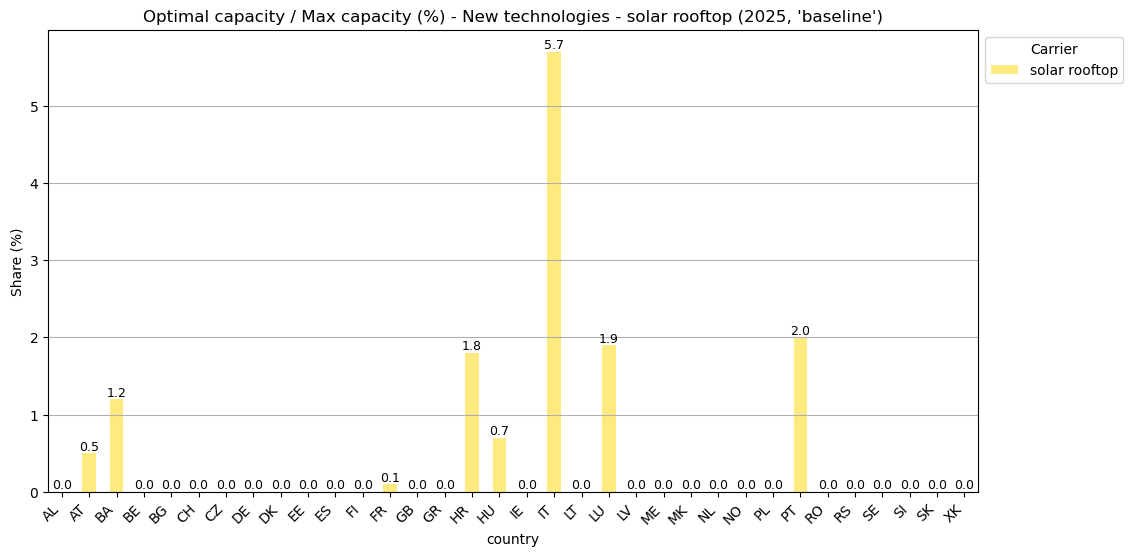

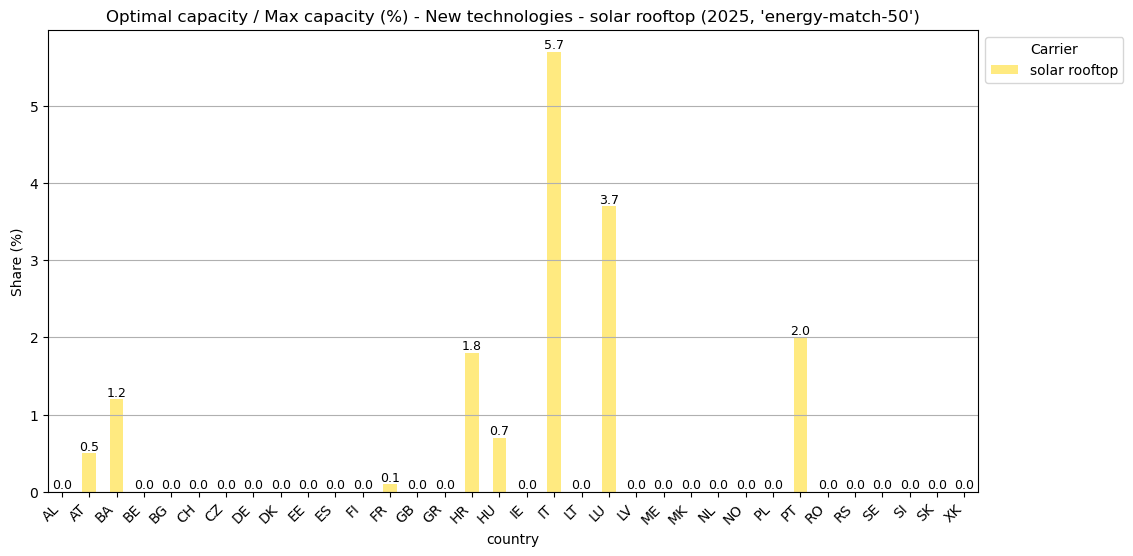

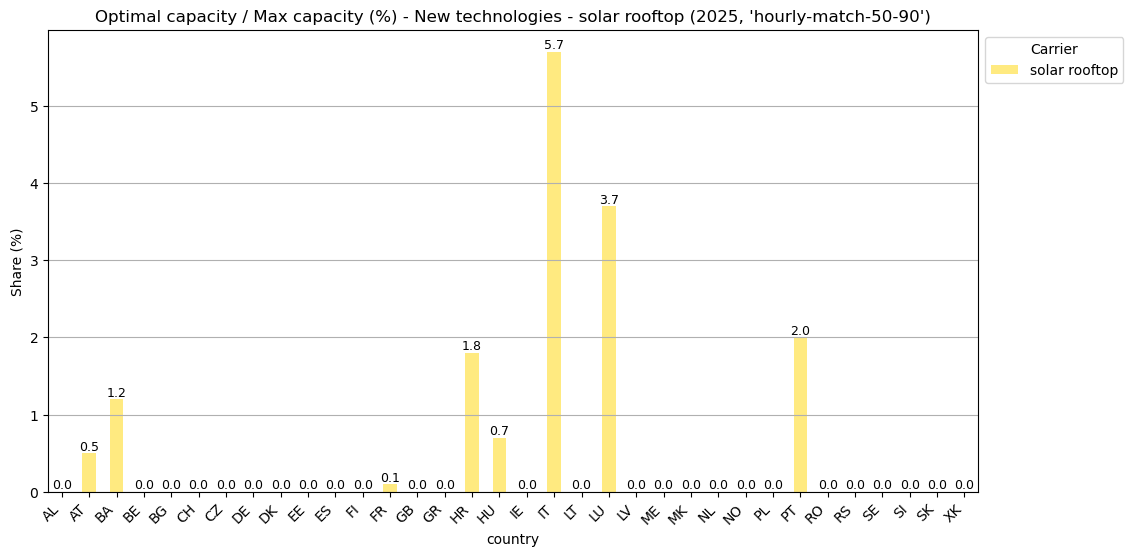

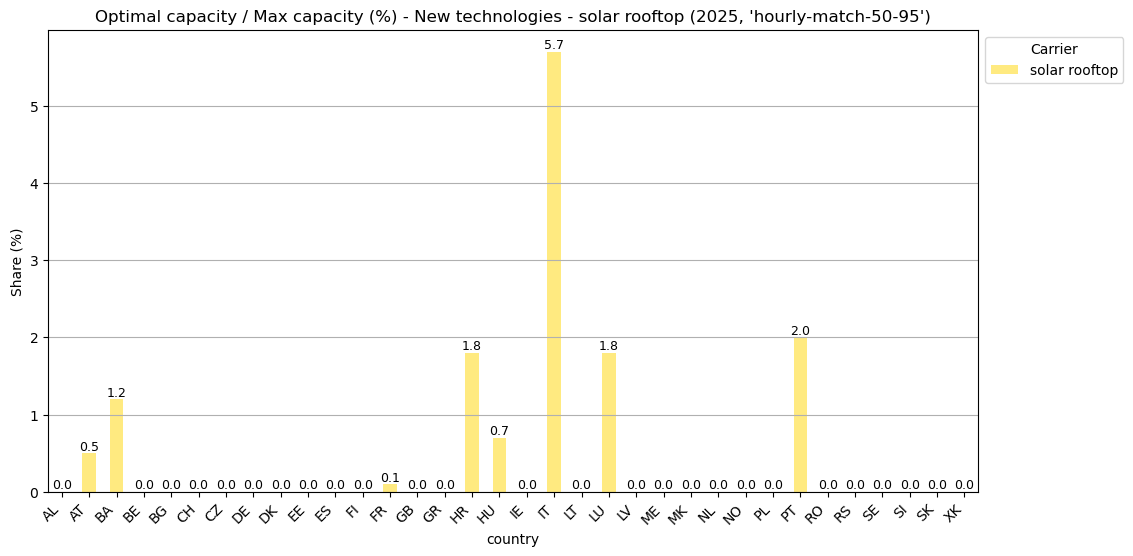

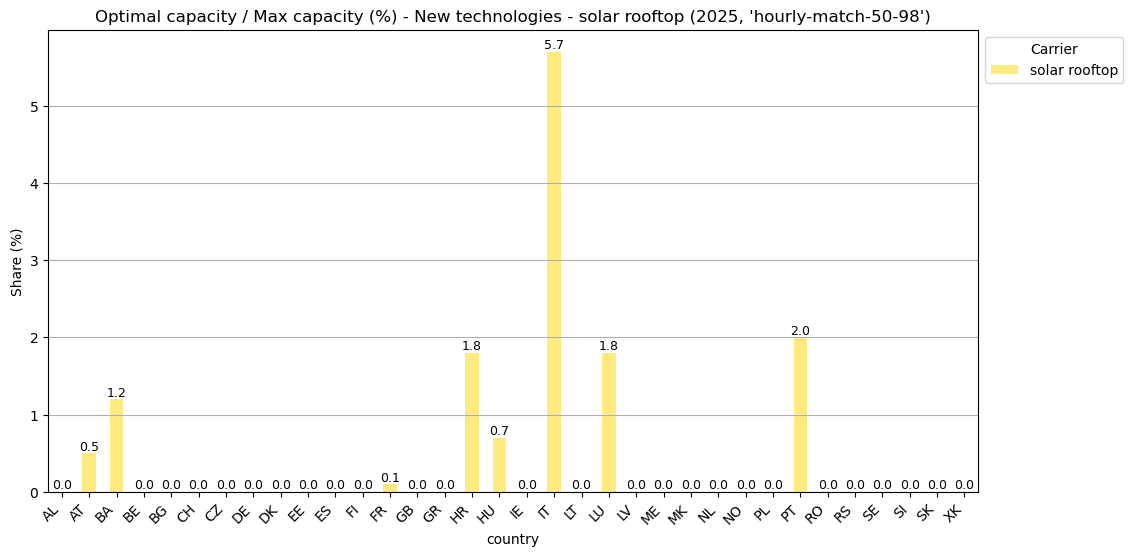

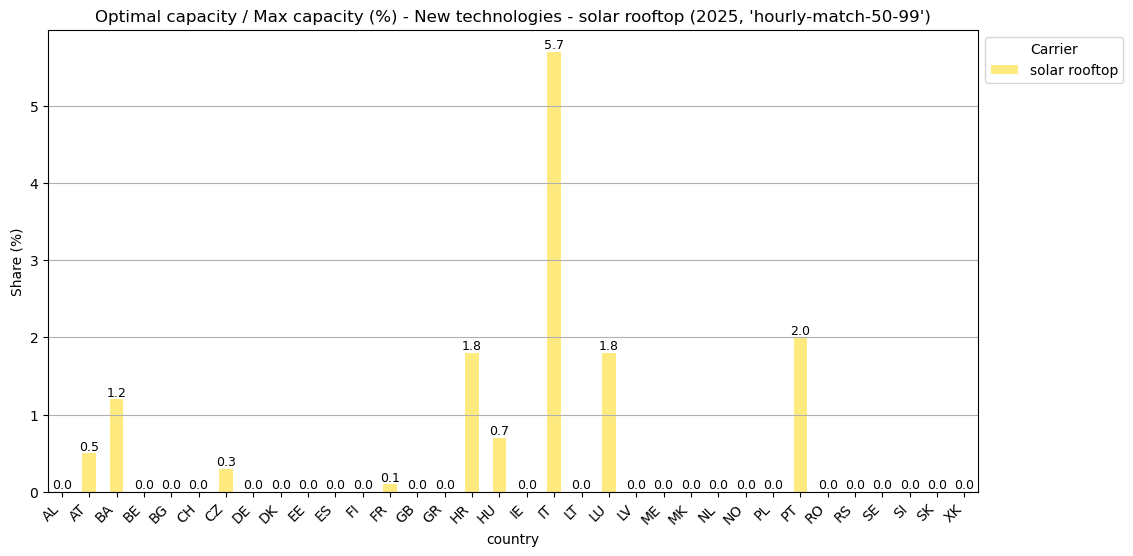

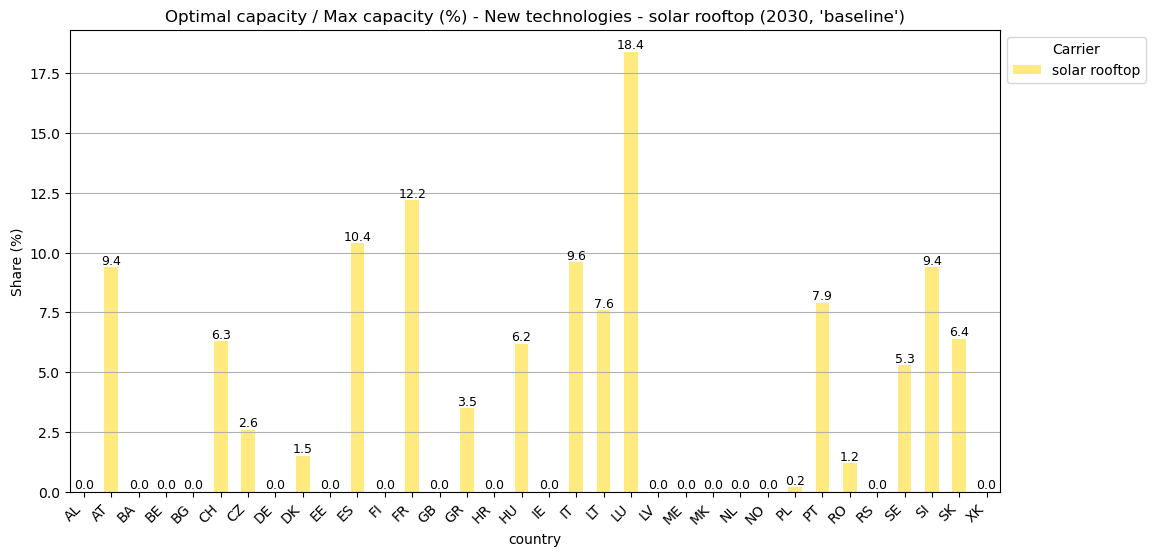

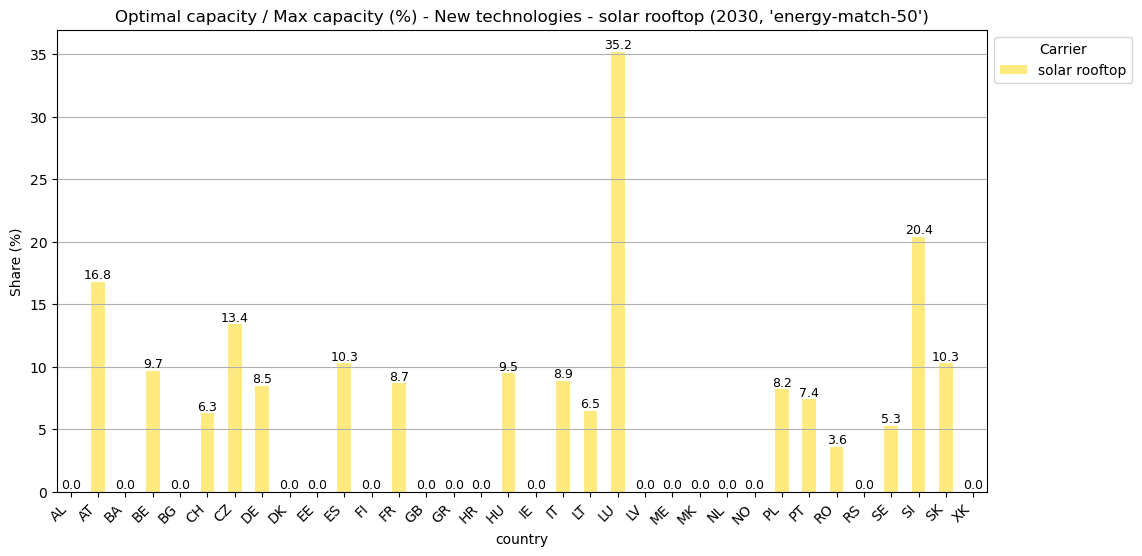

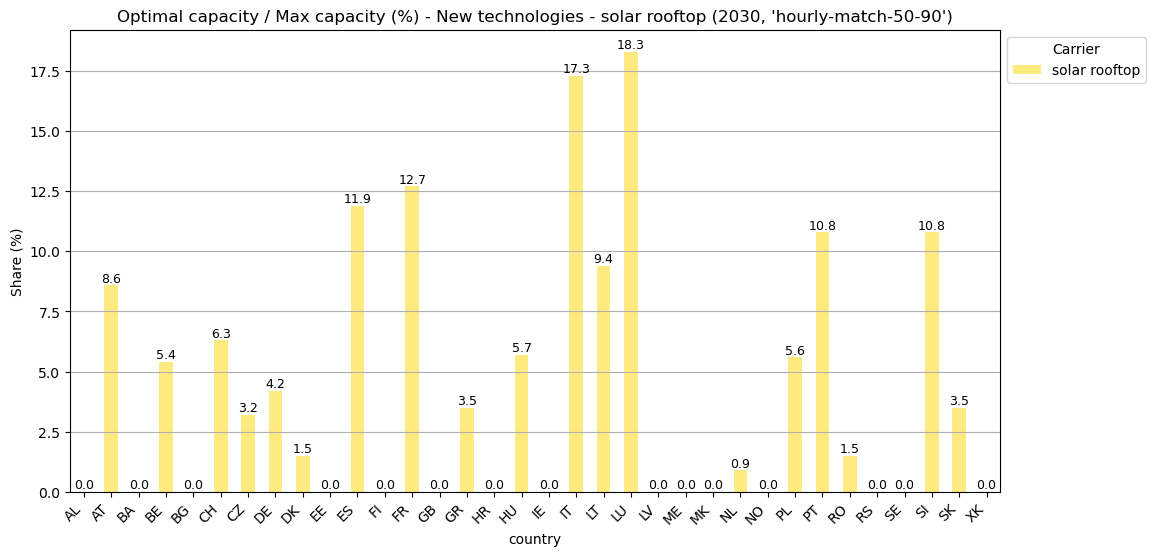

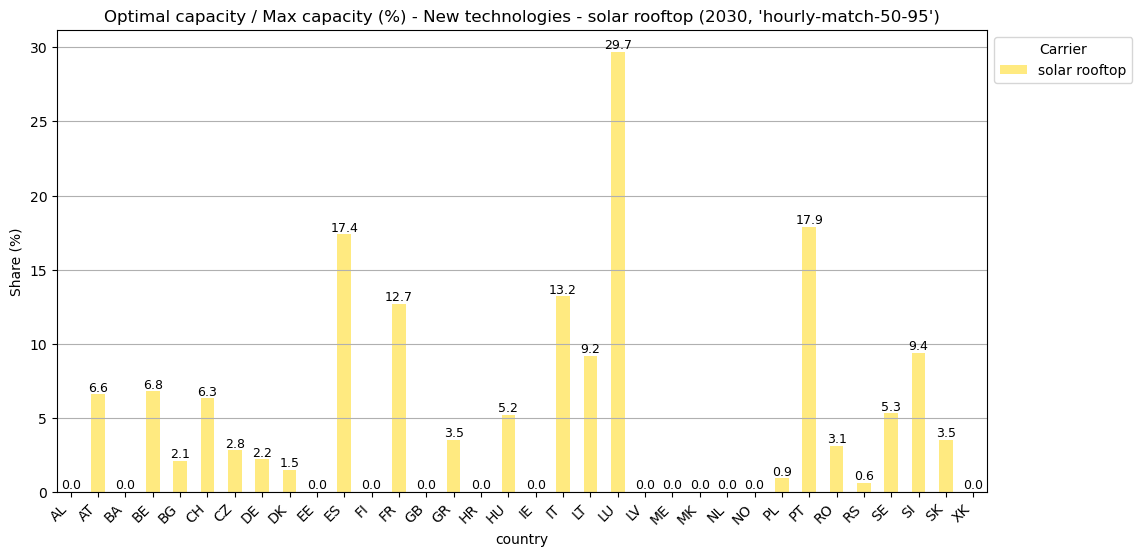

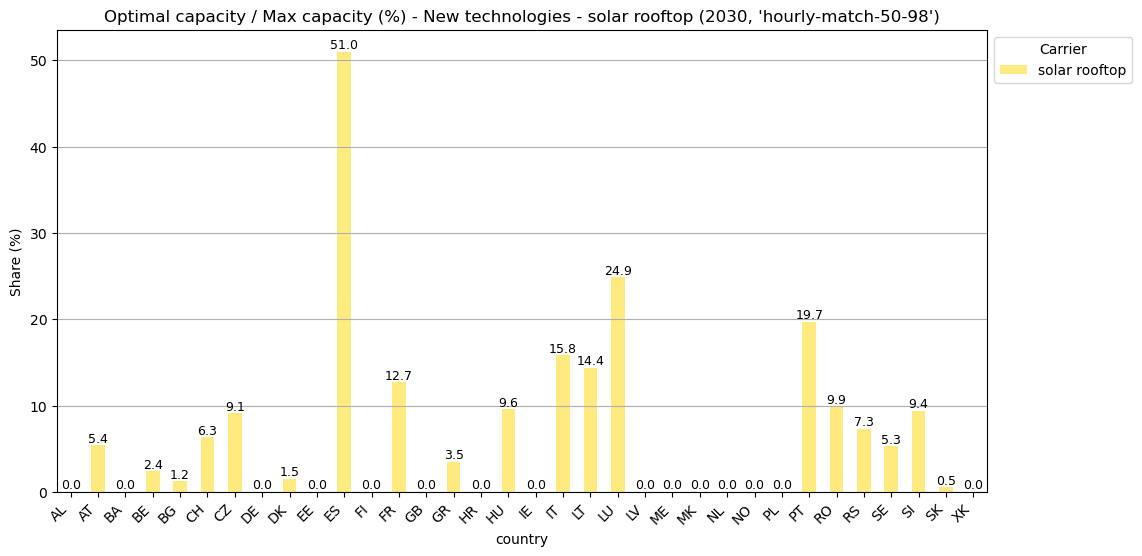

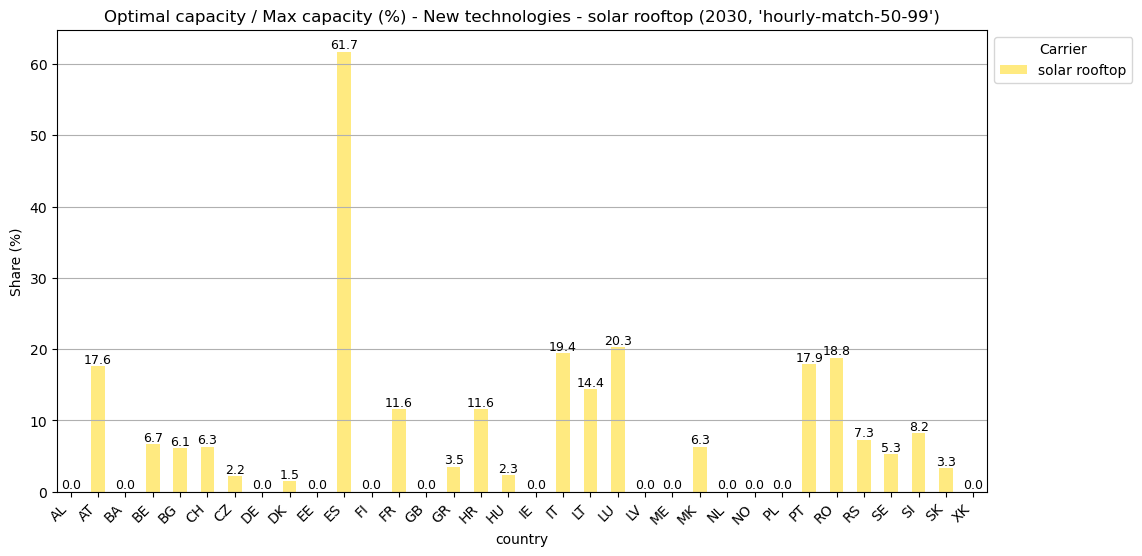

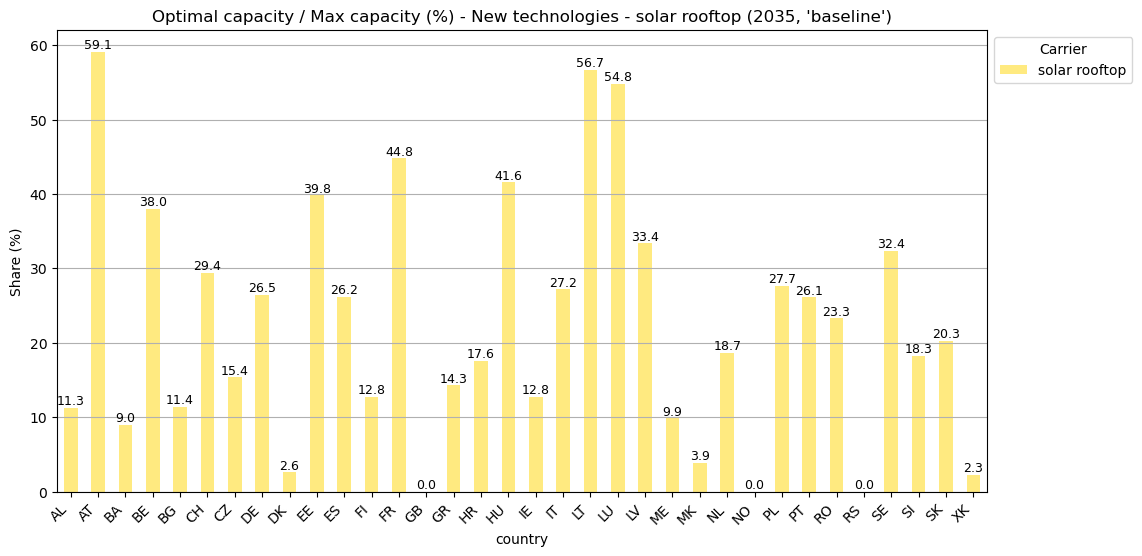

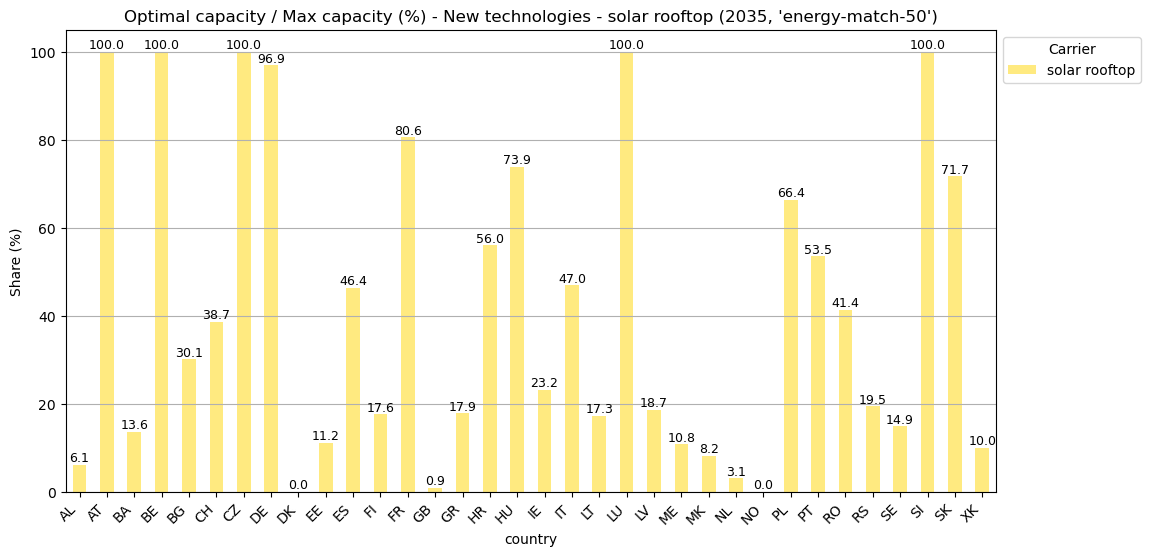

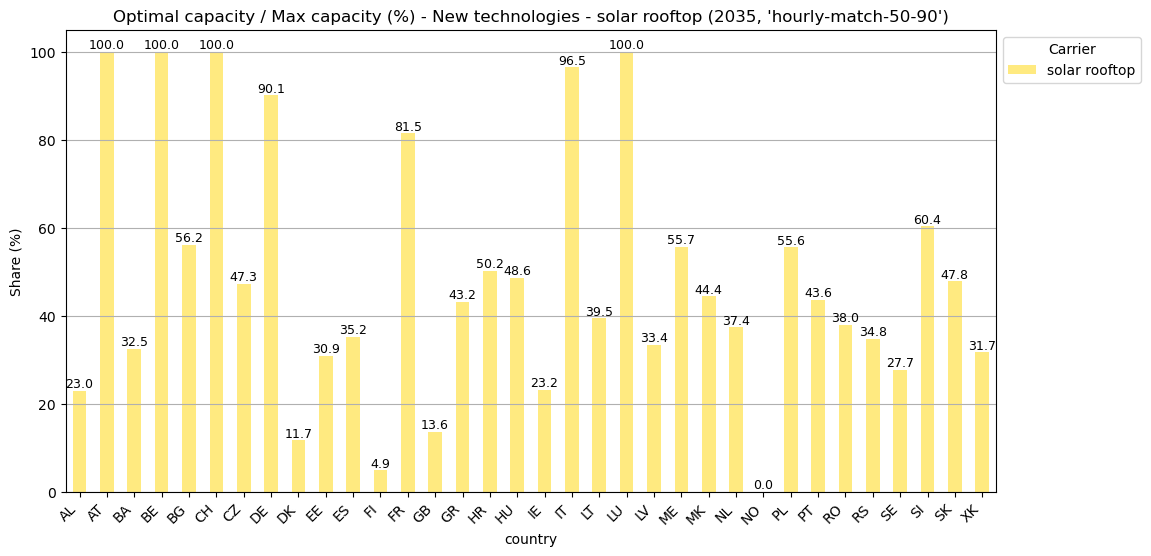

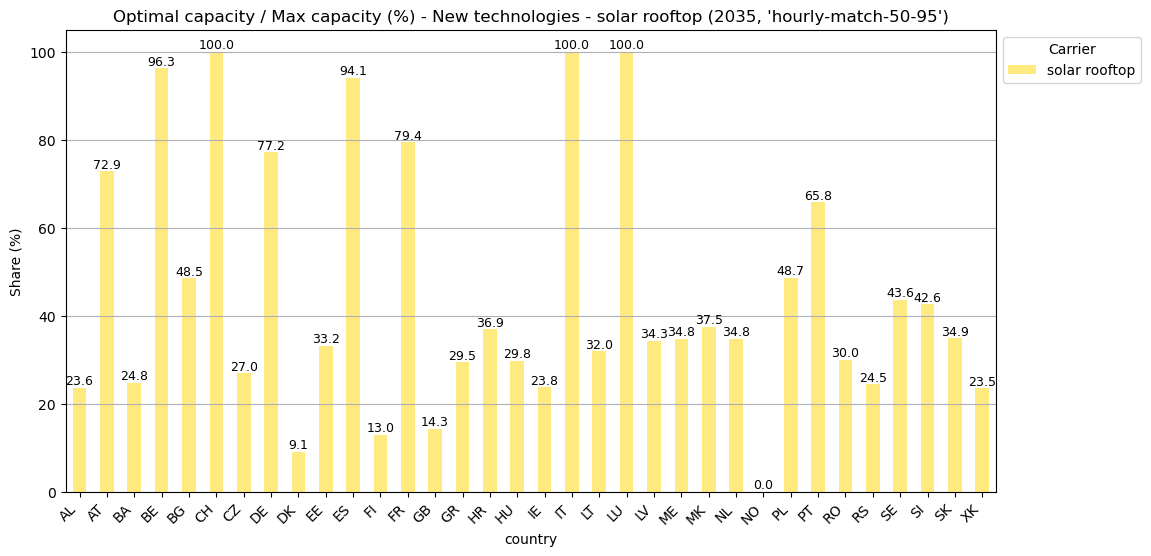

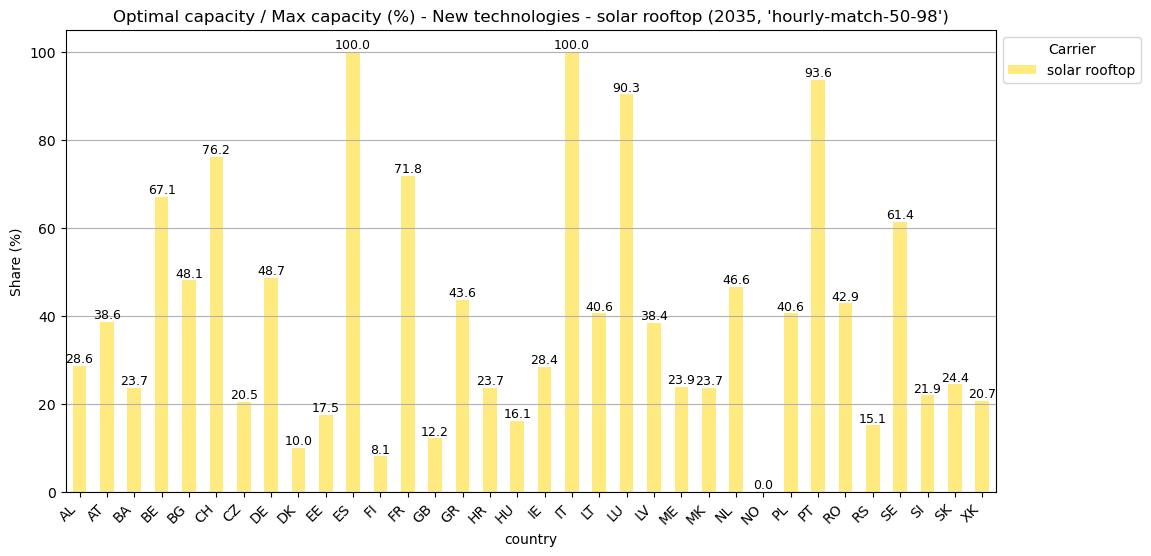

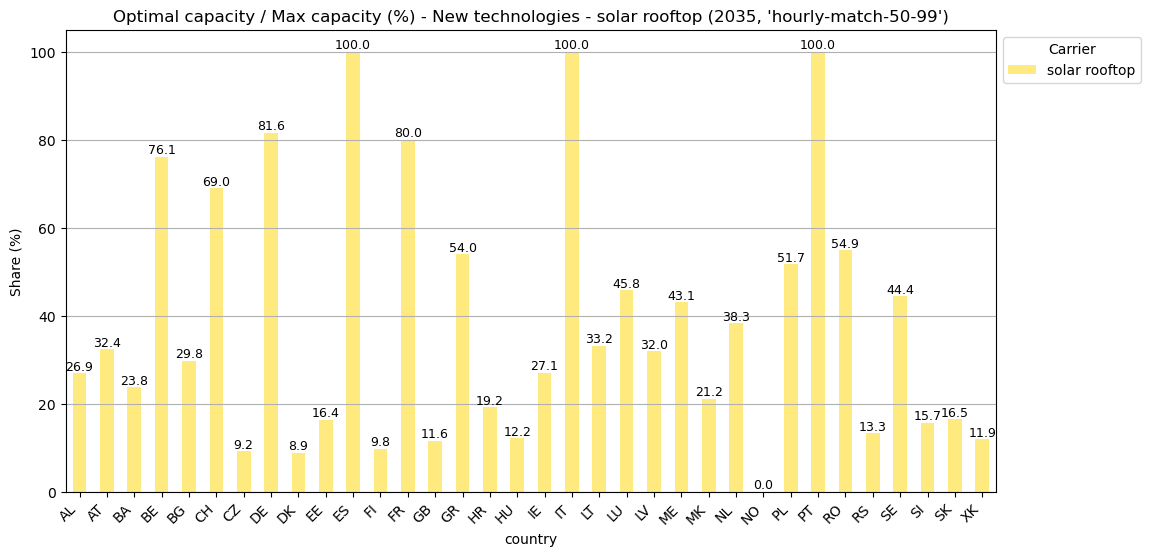

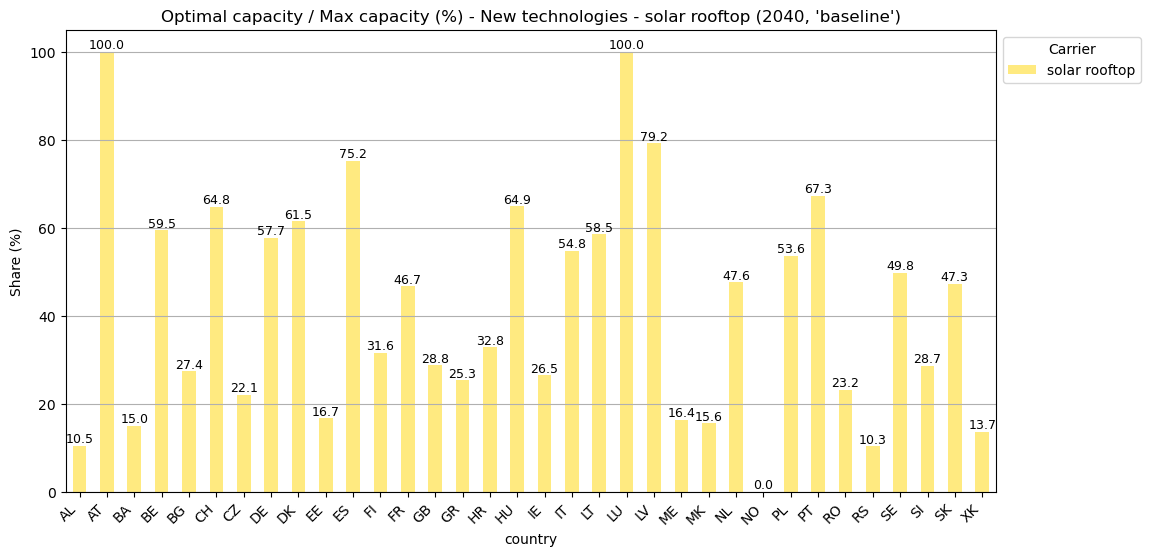

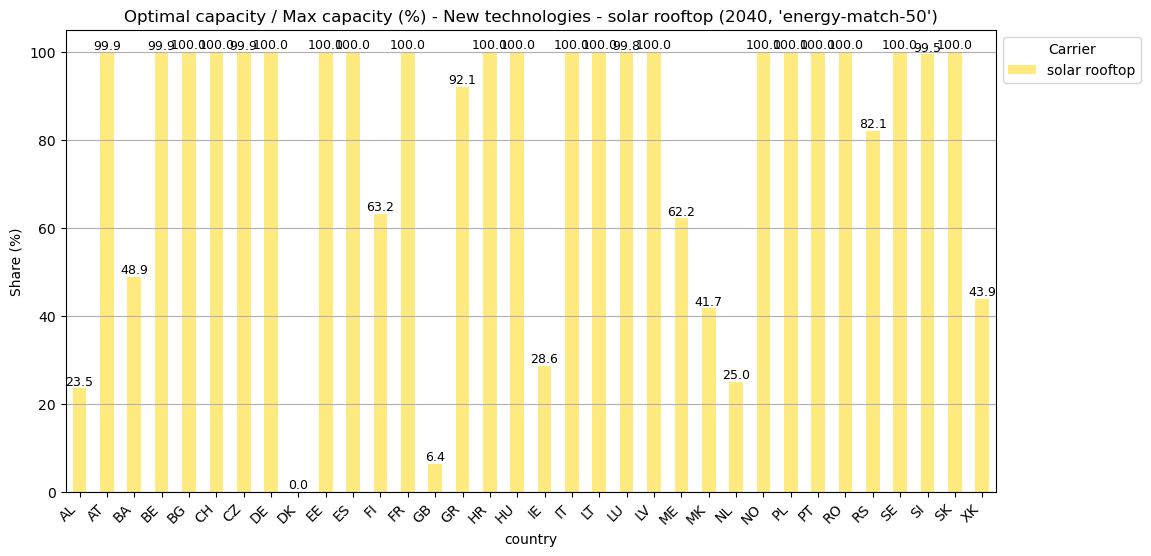

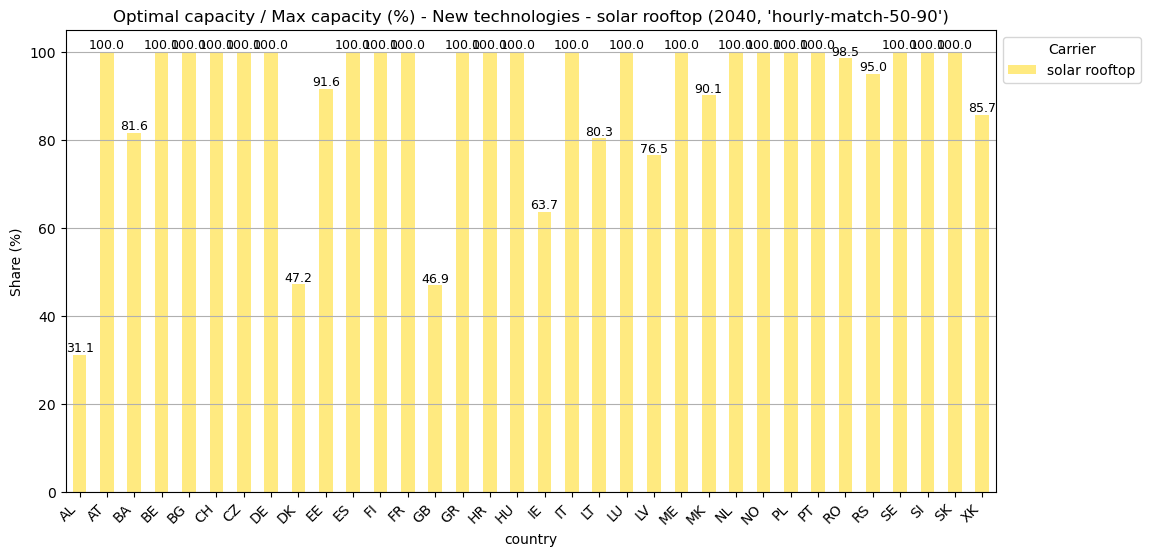

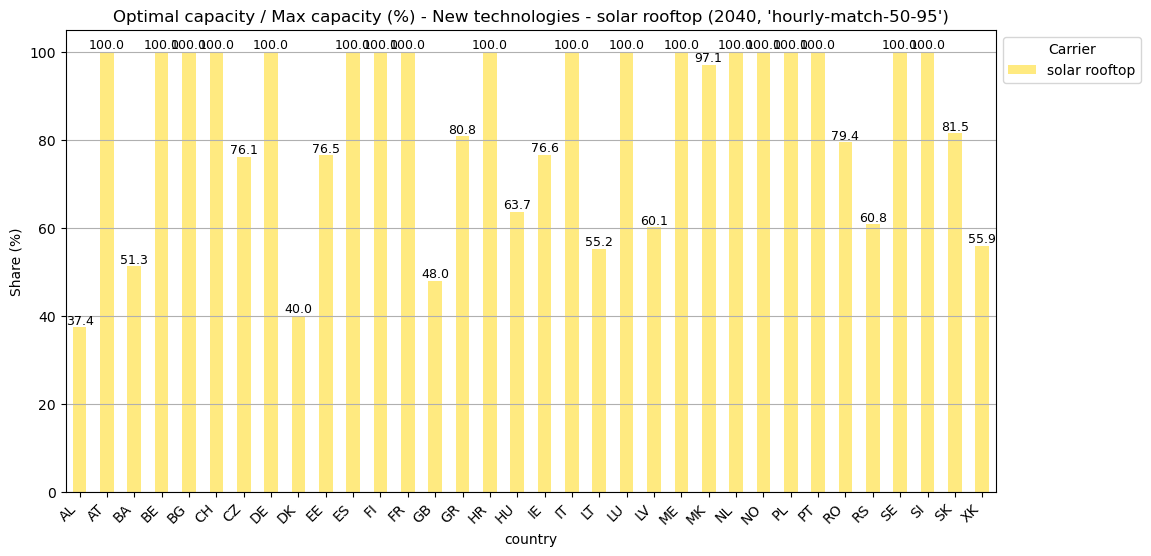

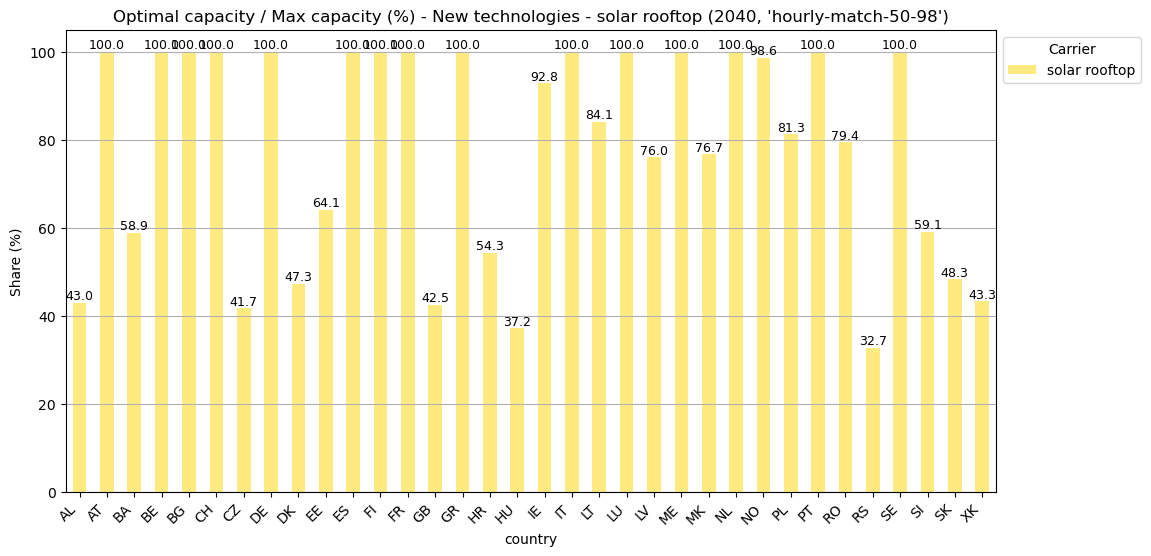

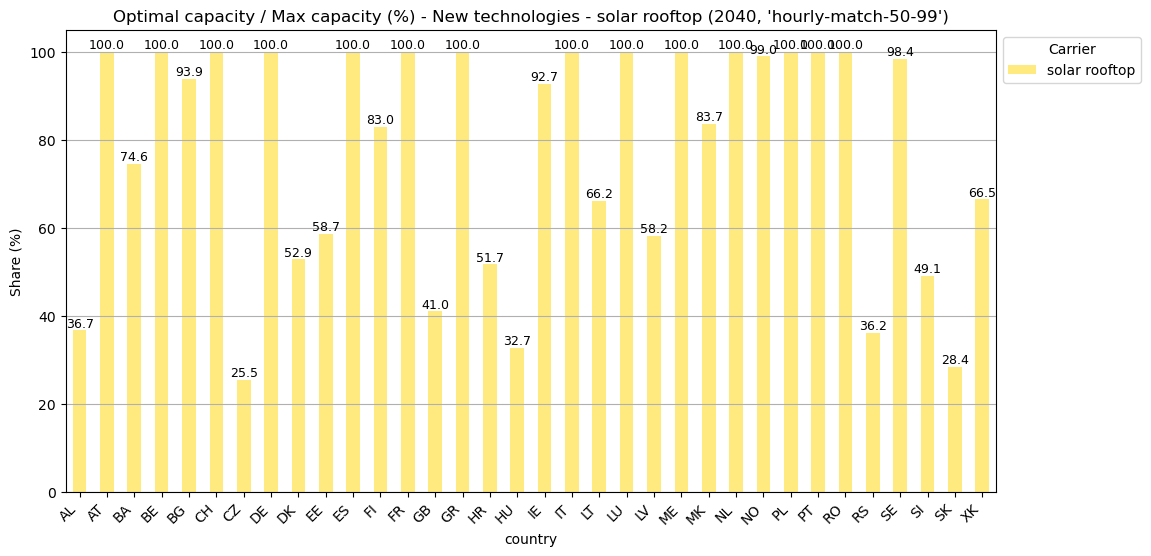

In [12]:
vres_carriers = [
        "solar",
        "solar rooftop",
        "solar-hsat",
        "onwind",
        "offwind-ac",
        "offwind-dc",
        "offwind-float",
    ]
df, colors = get_cap_all(df_networks["network"], carriers=vres_carriers, groupby_list=["carrier","country"])
df = df.drop("p_nom", axis=1, level=2)
#display(df)
years = df.columns.get_level_values('year').unique()
scenarios = df.columns.get_level_values('scenario').unique()
capacities = df.columns.get_level_values('capacity').unique()

# Use pd.IndexSlice for MultiIndex column selection
idx = pd.IndexSlice
df_plot = df.loc[:, idx[years, scenarios, "share over max"]]
df_plot = df_plot.droplevel('capacity', axis=1)
df_plot = df_plot*100
vres_plot = [
        #"solar",
        "solar utility", # solar + solar-hsat * 1.15 (see add_solar_potential_constraints in solve_network.py)
        "solar rooftop",
        #"solar-hsat",
        "onwind",
        "offwind-ac",
        "offwind-dc",
        "offwind-float",
    ]
vres_plot = ["solar rooftop"]
for carrier in vres_plot:
    print(f"-------------------------------------Analyzing {carrier}")
    if carrier not in df_plot.index:
        print(f"Warning: {carrier} not in df_plot index and will be skipped.")
        continue
    for scen in df_plot.columns:
        print(f"---------------Analyzing {scen}")
        df = df_plot[scen].unstack("country").loc[carrier,:].to_frame().T
        ax = plot_bar(df, colors[carrier], ylabel="Share (%)", title=f"Optimal capacity / Max capacity (%) - New technologies - {carrier} {scen}", vert_lines=False)